In [1]:
################################
# Notebook 09 – Visualisations
################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

# ---------------------------------------------------------
# 1. Load analysis base (main dataset)
# ---------------------------------------------------------
df = pd.read_csv("../data_clean/df_analysis_base.csv")

# Ensure one row per municipality
df = df.drop_duplicates(subset="municipality_code")

# ---------------------------------------------------------
# 2. Load geo data (contains province + coordinates)
# ---------------------------------------------------------
df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")

# Remove old geo columns if present
df = df.drop(columns=["longitude", "latitude"], errors="ignore")

# Merge geo information (province, longitude, latitude)
df = df.merge(
    df_geo[["municipality_code", "province", "longitude", "latitude"]],
    on="municipality_code",
    how="left"
)

# ---------------------------------------------------------
# 3. Copies for visualisations
# ---------------------------------------------------------
df_gemeenten = df.copy()

# GeoDataFrame for maps
df["geometry"] = df.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# ---------------------------------------------------------
# 4. Load residual dataset (for 5 residual visuals)
# ---------------------------------------------------------
df_residual = pd.read_csv("../data_clean/df_residual_2023.csv")

print("df loaded:", df.shape)
print("df_residual loaded:", df_residual.shape)


df loaded: (341, 69)
df_residual loaded: (341, 17)


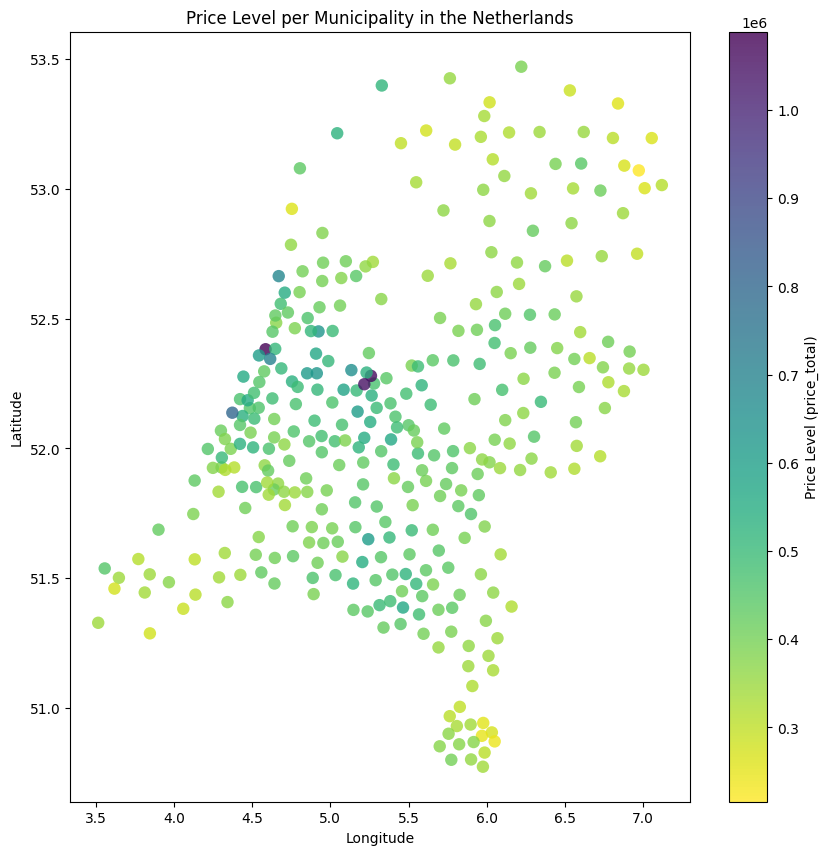

In [2]:
# -------------------------------------------
# Visual 1 – Price Level (price_total) per Municipality (Map)
# -------------------------------------------

plt.figure(figsize=(10, 10))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price_total"],
    cmap="viridis_r",   # inverted viridis: yellow = high, purple = low
    s=80,
    alpha=0.8,
    edgecolor="none"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Price Level (price_total)")

plt.title("Price Level per Municipality in the Netherlands")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


In [3]:
# ---------------------------------------------------------
# Compute deviation from provincial average (for Visual 2)
# ---------------------------------------------------------

# Ensure log_price_total exists
df["log_price_total"] = np.log(df["price_total"])

# Compute provincial mean log price
df["province_mean_log_price"] = (
    df.groupby("province")["log_price_total"].transform("mean")
)

# Compute deviation
df["price_deviation_from_province"] = (
    df["log_price_total"] - df["province_mean_log_price"]
)


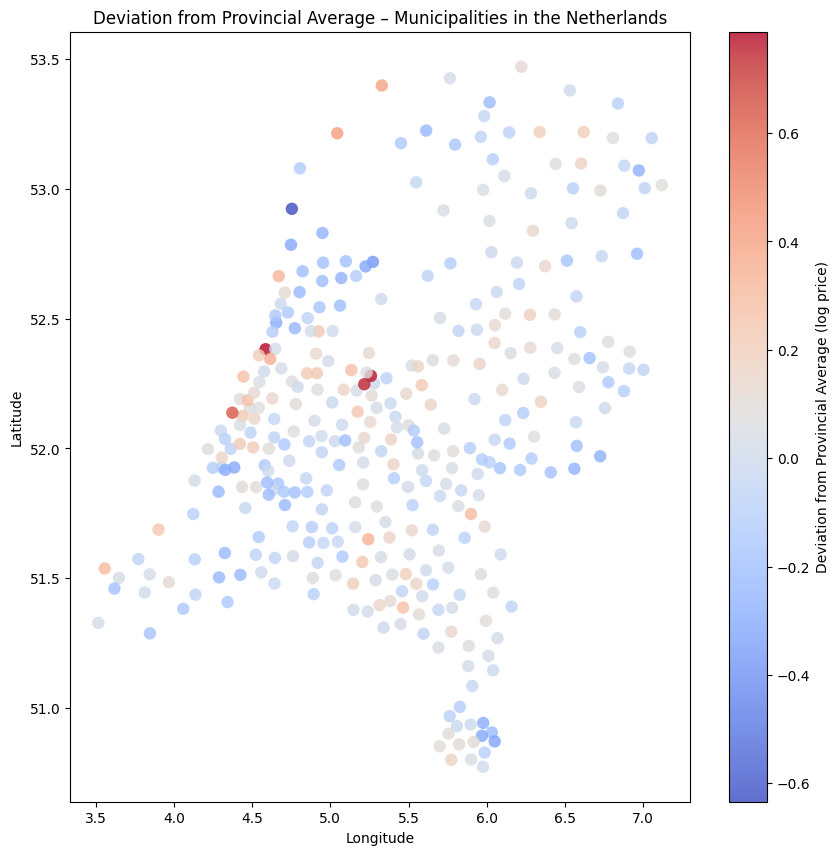

In [4]:
# -------------------------------------------------------------------
# Visual 2 – Deviation from Provincial Average (Map)
# -------------------------------------------------------------------

plt.figure(figsize=(10, 10))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price_deviation_from_province"],
    cmap="coolwarm",     # red = above avg, blue = below avg
    s=80,
    alpha=0.8,
    edgecolor="none"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Deviation from Provincial Average (log price)")

plt.title("Deviation from Provincial Average – Municipalities in the Netherlands")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


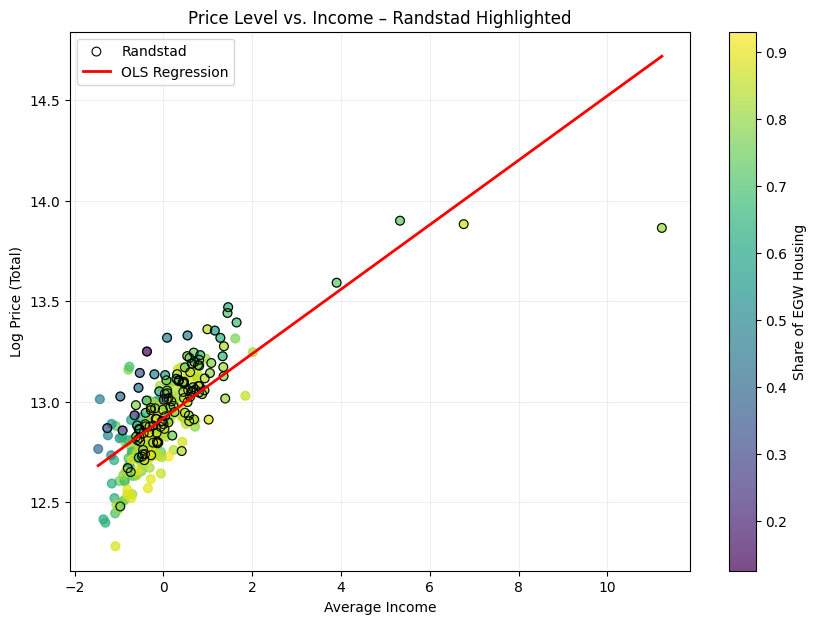

In [5]:
# ---------------------------------------------------------
# Visual 3 – Price Level vs. Income (with Regression & Randstad Highlight)
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Scatter: all municipalities
scatter = plt.scatter(
    df_gemeenten["income_mean"],
    df_gemeenten["log_price_total"],
    c=df_gemeenten["share_egw"],
    cmap="viridis",
    alpha=0.7,
    s=40
)

# 2. Highlight Randstad municipalities
randstad = df_gemeenten[df_gemeenten["is_randstad"] == 1]

plt.scatter(
    randstad["income_mean"],
    randstad["log_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression line
X = sm.add_constant(df_gemeenten["income_mean"])
y = df_gemeenten["log_price_total"]
model = sm.OLS(y, X).fit()

x_vals = np.linspace(
    df_gemeenten["income_mean"].min(),
    df_gemeenten["income_mean"].max(),
    200
)
y_pred = model.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS Regression"
)

# 4. Labels, title, legend
plt.colorbar(scatter, label="Share of EGW Housing")
plt.xlabel("Average Income")
plt.ylabel("Log Price (Total)")
plt.title("Price Level vs. Income – Randstad Highlighted")
plt.grid(alpha=0.2)
plt.legend()

plt.show()


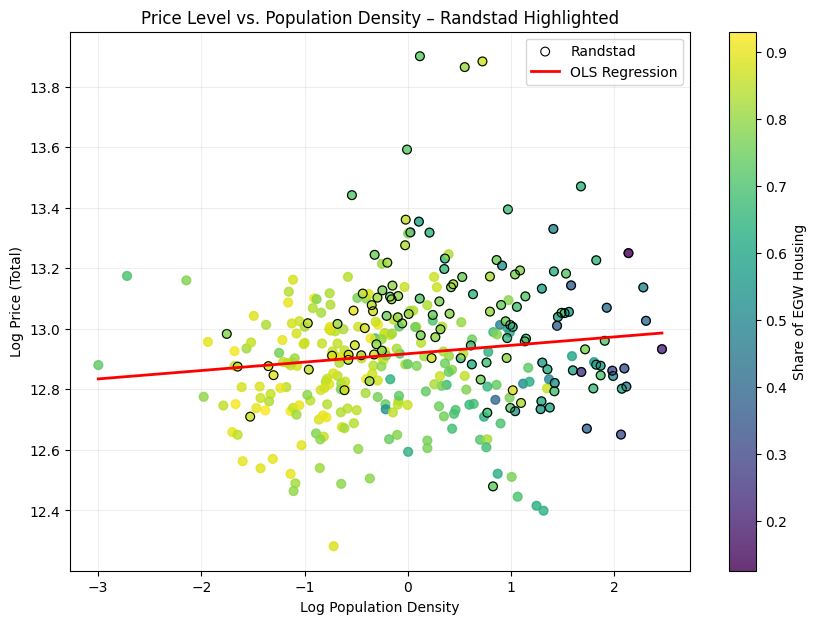

In [6]:
# ---------------------------------------------------------
# Visual 4 – Price Level vs. Population Density
# with Regression & Randstad Highlight
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Scatter: all municipalities
scatter = plt.scatter(
    df_gemeenten["log_density"],
    df_gemeenten["log_price_total"],
    c=df_gemeenten["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Highlight Randstad municipalities
randstad = df_gemeenten[df_gemeenten["is_randstad"] == 1]

plt.scatter(
    randstad["log_density"],
    randstad["log_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression (OLS)
X = sm.add_constant(df_gemeenten["log_density"])
y = df_gemeenten["log_price_total"]
model = sm.OLS(y, X).fit()

x_vals = np.linspace(
    df_gemeenten["log_density"].min(),
    df_gemeenten["log_density"].max(),
    200
)
y_pred = model.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS Regression"
)

# 4. Labels, title, layout
plt.colorbar(scatter, label="Share of EGW Housing")
plt.xlabel("Log Population Density")
plt.ylabel("Log Price (Total)")
plt.title("Price Level vs. Population Density – Randstad Highlighted")
plt.grid(alpha=0.2)
plt.legend()

plt.show()


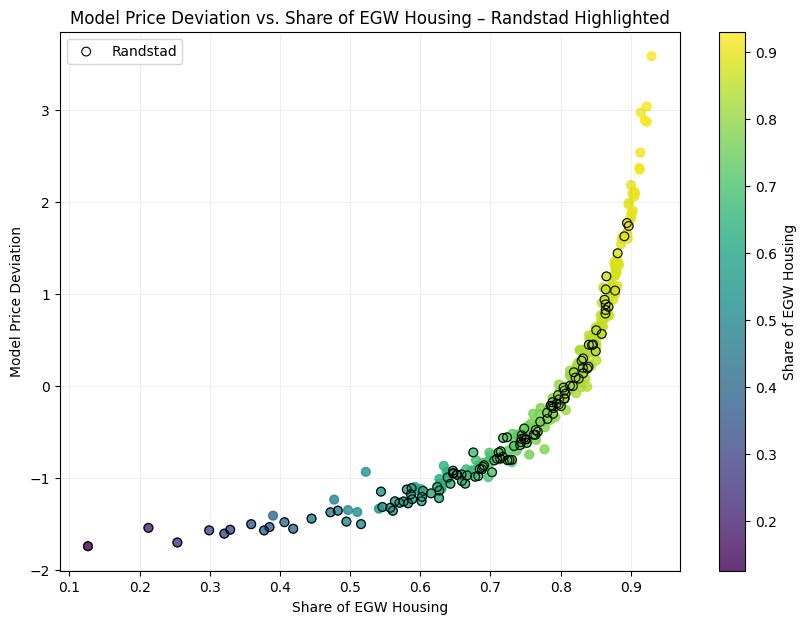

In [7]:
# ---------------------------------------------------------
# Visual 5 – Model Price Deviation vs. Share of EGW Housing
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Scatter: all municipalities
scatter = plt.scatter(
    df_gemeenten["share_egw"],
    df_gemeenten["ratio_price_model"],
    c=df_gemeenten["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Highlight Randstad municipalities
randstad = df_gemeenten[df_gemeenten["is_randstad"] == 1]

plt.scatter(
    randstad["share_egw"],
    randstad["ratio_price_model"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Regression (optional – still commented out)
# X = sm.add_constant(df_gemeenten["share_egw"])
# y = df_gemeenten["ratio_price_model"]
# model = sm.OLS(y, X).fit()
#
# x_vals = np.linspace(
#     df_gemeenten["share_egw"].min(),
#     df_gemeenten["share_egw"].max(),
#     200
# )
# y_pred = model.predict(sm.add_constant(x_vals))
#
# plt.plot(
#     x_vals,
#     y_pred,
#     color="red",
#     linewidth=2,
#     label="OLS Regression"
# )

# 4. Labels, title, layout
plt.colorbar(scatter, label="Share of EGW Housing")
plt.xlabel("Share of EGW Housing")
plt.ylabel("Model Price Deviation")
plt.title("Model Price Deviation vs. Share of EGW Housing – Randstad Highlighted")
plt.grid(alpha=0.2)
plt.legend()

plt.show()


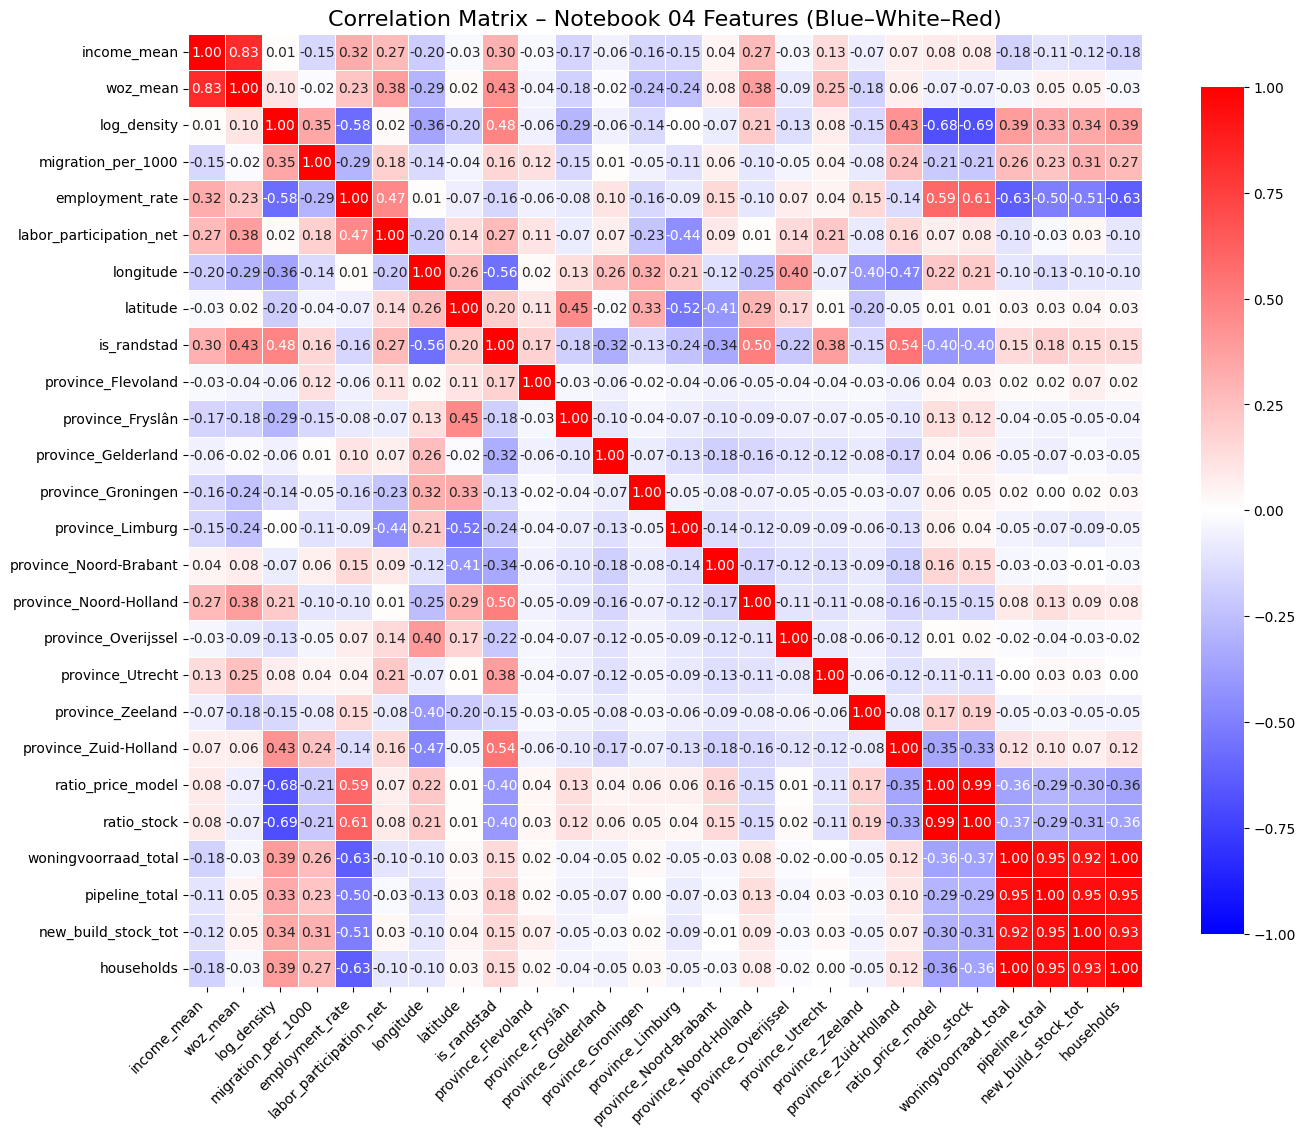

In [8]:
# ---------------------------------------------------------
# Visual 6.1 – Correlation Heatmap (Notebook 04 Features)
# Blue = -1, White = 0, Red = +1
# ---------------------------------------------------------

plt.figure(figsize=(14, 12))

# 1. Feature list from Notebook 04
features_nb04 = [
    'income_mean',
    'woz_mean',
    'log_density',
    'migration_per_1000',
    'employment_rate',
    'labor_participation_net',
    'longitude',
    'latitude',
    'is_randstad',
    'province_Flevoland',
    'province_Fryslân',
    'province_Gelderland',
    'province_Groningen',
    'province_Limburg',
    'province_Noord-Brabant',
    'province_Noord-Holland',
    'province_Overijssel',
    'province_Utrecht',
    'province_Zeeland',
    'province_Zuid-Holland',
    'ratio_price_model',
    'ratio_stock',
    'woningvoorraad_total',
    'pipeline_total',
    'new_build_stock_tot',
    'households'
]

# 2. Compute correlation matrix
corr = df_gemeenten[features_nb04].corr()

# 3. Draw heatmap
sns.heatmap(
    corr,
    cmap="bwr",          # Blue–White–Red
    vmin=-1, vmax=1,     # fixed scale
    center=0,            # white = 0
    annot=True,          # show numbers
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix – Notebook 04 Features (Blue–White–Red)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


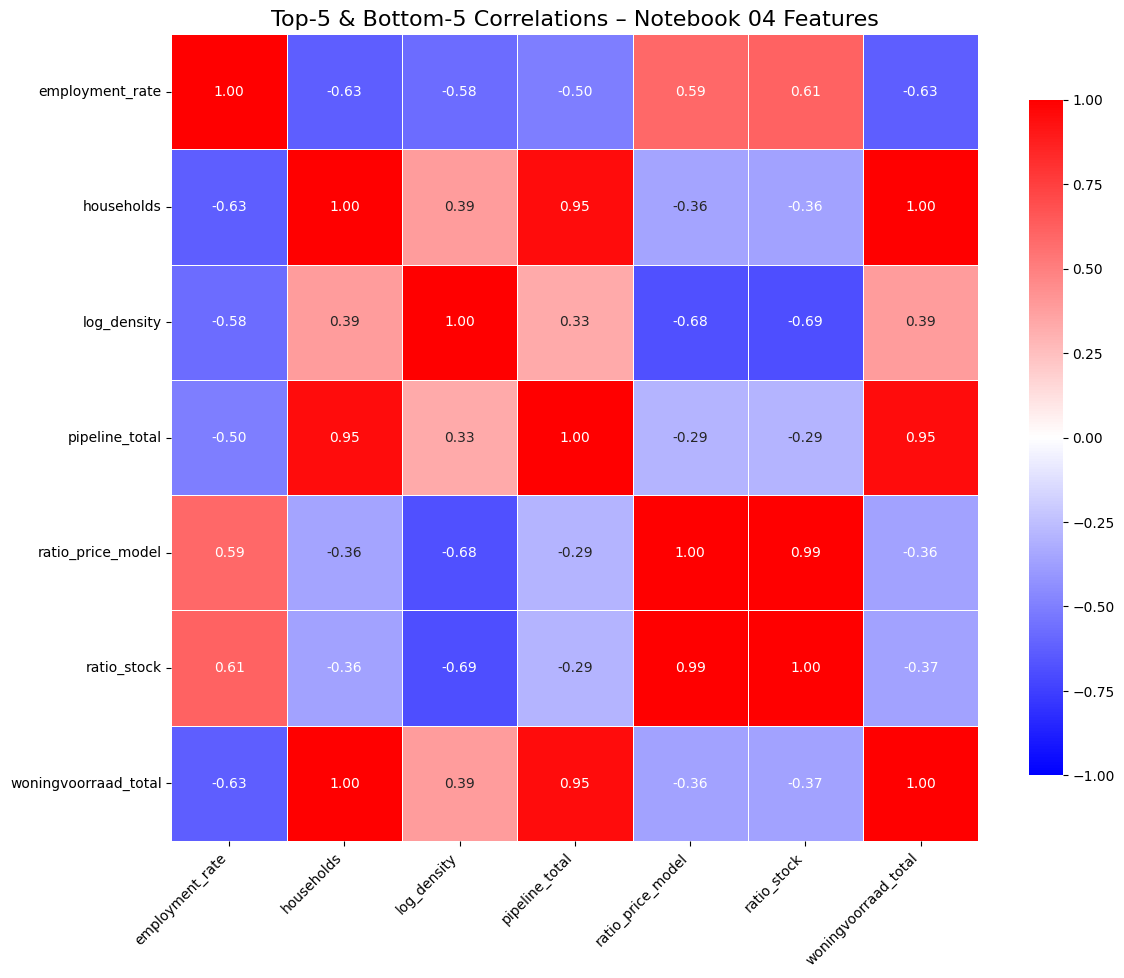

In [9]:
# ---------------------------------------------------------
# Visual 6.2 – Top‑5 & Bottom‑5 Correlations (Notebook 04 Features)
# ---------------------------------------------------------

plt.figure(figsize=(12, 10))

# 1. Feature list from Notebook 04
features_nb04 = [
    'income_mean',
    'woz_mean',
    'log_density',
    'migration_per_1000',
    'employment_rate',
    'labor_participation_net',
    'longitude',
    'latitude',
    'is_randstad',
    'province_Flevoland',
    'province_Fryslân',
    'province_Gelderland',
    'province_Groningen',
    'province_Limburg',
    'province_Noord-Brabant',
    'province_Noord-Holland',
    'province_Overijssel',
    'province_Utrecht',
    'province_Zeeland',
    'province_Zuid-Holland',
    'ratio_price_model',
    'ratio_stock',
    'woningvoorraad_total',
    'pipeline_total',
    'new_build_stock_tot',
    'households'
]

# 2. Compute correlation matrix
corr = df_gemeenten[features_nb04].corr()

# 3. Convert to long format (remove diagonal)
corr_long = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .reset_index()
)
corr_long.columns = ["var1", "var2", "corr"]

# 4. Select Top‑5 and Bottom‑5 correlations
top5 = corr_long.nlargest(5, "corr")
bottom5 = corr_long.nsmallest(5, "corr")

selected_pairs = pd.concat([top5, bottom5])

# 5. Collect all variables involved
selected_vars = sorted(set(selected_pairs["var1"]) | set(selected_pairs["var2"]))

# 6. Extract submatrix
corr_sub = corr.loc[selected_vars, selected_vars]

# 7. Draw heatmap
sns.heatmap(
    corr_sub,
    cmap="bwr",
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Top‑5 & Bottom‑5 Correlations – Notebook 04 Features", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


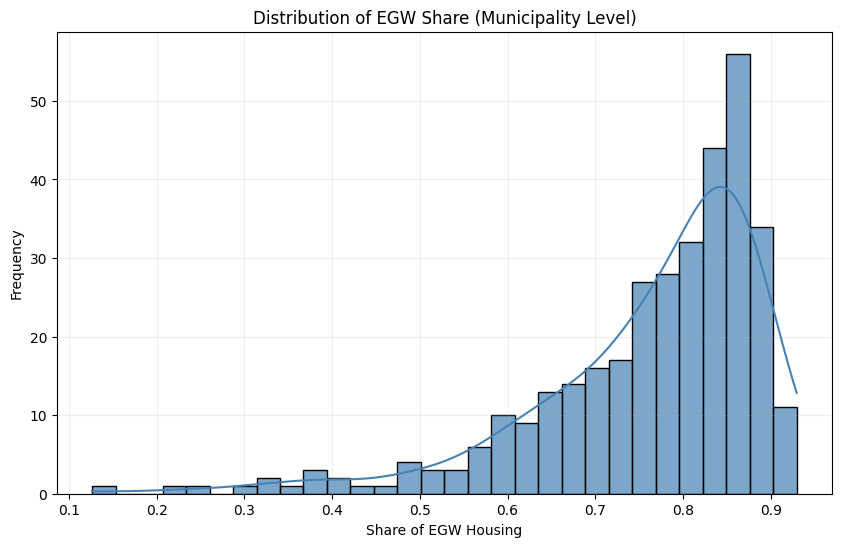

In [10]:
# ---------------------------------------------------------
# Visual 7 – Distribution of EGW Share (Histogram)
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df_gemeenten["share_egw"],
    bins=30,
    kde=True,
    color="steelblue",
    alpha=0.7
)

plt.xlabel("Share of EGW Housing")
plt.ylabel("Frequency")
plt.title("Distribution of EGW Share (Municipality Level)")
plt.grid(alpha=0.2)

plt.show()


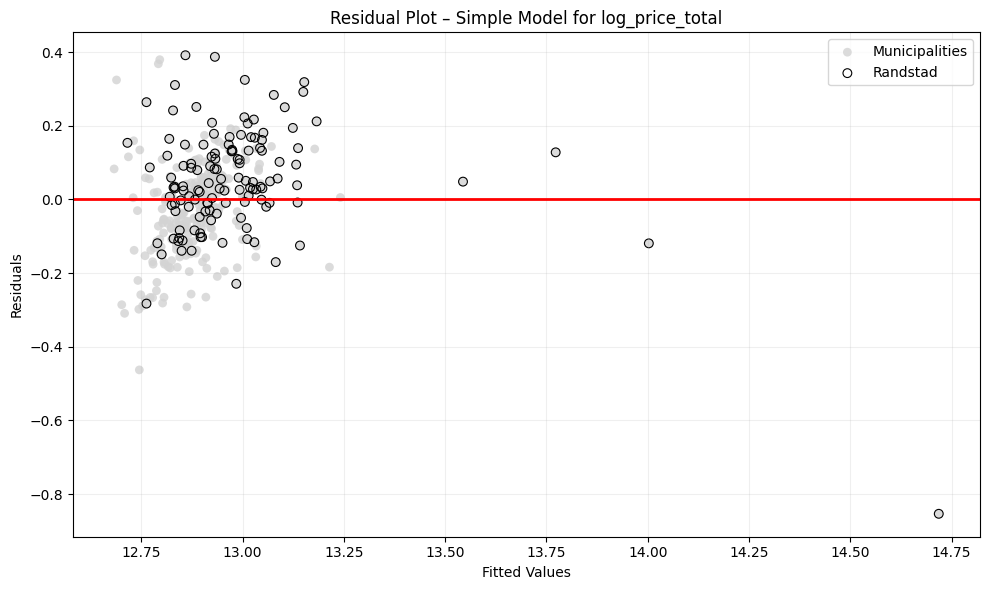

In [11]:
# ---------------------------------------------------------
# Visual 8 – Residual Plot (High Contrast Randstad Highlight)
# ---------------------------------------------------------

# 1. Simple numeric model
X = df_gemeenten[["income_mean"]].apply(pd.to_numeric, errors="coerce")
X = sm.add_constant(X)
y = pd.to_numeric(df_gemeenten["log_price_total"], errors="coerce")

model_df = pd.concat([y, X], axis=1).dropna()
y_clean = model_df["log_price_total"]
X_clean = model_df.drop(columns=["log_price_total"])

model_total = sm.OLS(y_clean, X_clean).fit()

# 2. Residuals & fitted values
residuals = model_total.resid
fitted = model_total.fittedvalues

# 3. Randstad mask
randstad_mask = df_gemeenten.loc[model_df.index, "is_randstad"] == 1


plt.figure(figsize=(10, 6))

# 1. All municipalities in neutral grey
plt.scatter(
    fitted,
    residuals,
    alpha=0.8,
    color="lightgrey",
    edgecolor="none",
    s=40,
    label="Municipalities"
)

# 2. Randstad highlighted with black circles
plt.scatter(
    fitted[randstad_mask],
    residuals[randstad_mask],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. Zero line
plt.axhline(0, color="red", linewidth=2)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot – Simple Model for log_price_total")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


<Figure size 1200x1200 with 0 Axes>

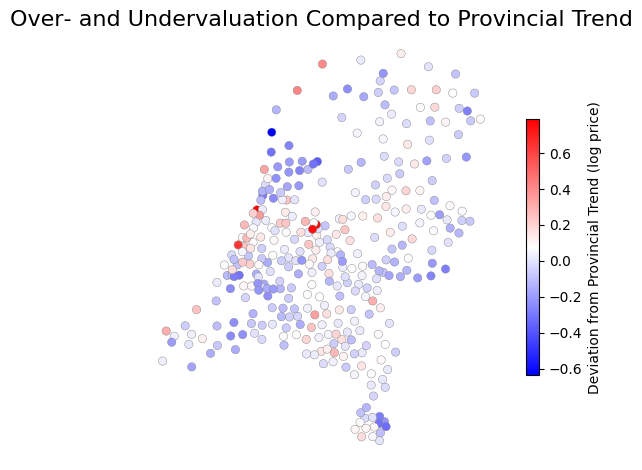

In [12]:
# ---------------------------------------------------------
# Compute deviation from provincial average (needed for Visual 9)
# ---------------------------------------------------------

# Ensure log_price_total exists
df["log_price_total"] = np.log(df["price_total"])

# Compute provincial mean log price
df["province_mean_log_price"] = (
    df.groupby("province")["log_price_total"].transform("mean")
)

# Compute deviation
df["price_deviation_from_province"] = (
    df["log_price_total"] - df["province_mean_log_price"]
)

# ---------------------------------------------------------
# Update gdf so it includes the new deviation column
# ---------------------------------------------------------

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# ---------------------------------------------------------
# Visual 9 – Over‑ and Undervaluation Relative to Provincial Trend
# ---------------------------------------------------------

plt.figure(figsize=(12, 12))

# Color scale limits
vmin = gdf["price_deviation_from_province"].min()
vmax = gdf["price_deviation_from_province"].max()

gdf.plot(
    column="price_deviation_from_province",
    cmap="bwr",                     # blue = undervalued, red = overvalued
    linewidth=0.3,
    edgecolor="gray",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={
        "shrink": 0.6,
        "label": "Deviation from Provincial Trend (log price)"
    }
)

plt.title("Over‑ and Undervaluation Compared to Provincial Trend", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()



In [13]:
# ---------------------------------------------------------
# Merge df_residual_2023 with df to get Randstad + EGW info
# ---------------------------------------------------------

df_woz = df_residual.merge(
    df[["municipality_code", "share_egw", "is_randstad"]],
    on="municipality_code",
    how="left"
)


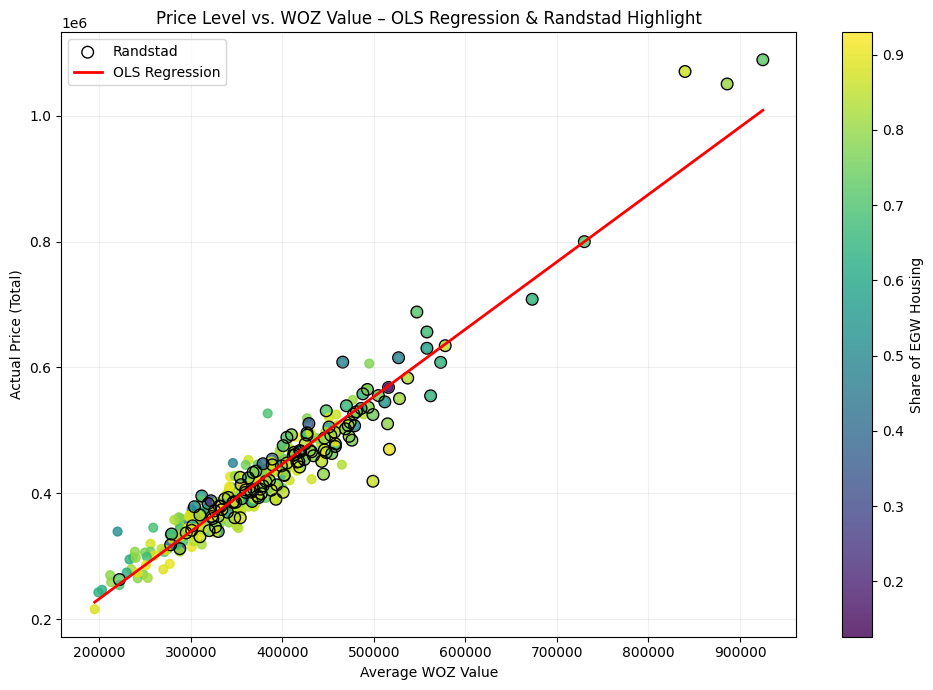

In [14]:
# ---------------------------------------------------------
# Visual 10 – Price vs. WOZ (Scatter + Regression)
# using df_residual (correct WOZ values)
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Scatterplot (all municipalities)
scatter = plt.scatter(
    df_residual["woz_mean"],
    df_residual["price_total"],
    c=df_residual["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Highlight Randstad municipalities
randstad = df_residual[df_residual["is_randstad"] == 1]

plt.scatter(
    randstad["woz_mean"],
    randstad["price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    s=70,
    label="Randstad"
)

# 3. Regression
X = sm.add_constant(df_residual["woz_mean"])
y = df_residual["price_total"]
model_woz = sm.OLS(y, X).fit()

x_vals = np.linspace(df_residual["woz_mean"].min(),
                     df_residual["woz_mean"].max(), 200)
y_pred = model_woz.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS Regression"
)

# 4. Labels, title, legend
plt.colorbar(scatter, label="Share of EGW Housing")
plt.xlabel("Average WOZ Value")
plt.ylabel("Actual Price (Total)")
plt.title("Price Level vs. WOZ Value – OLS Regression & Randstad Highlight")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


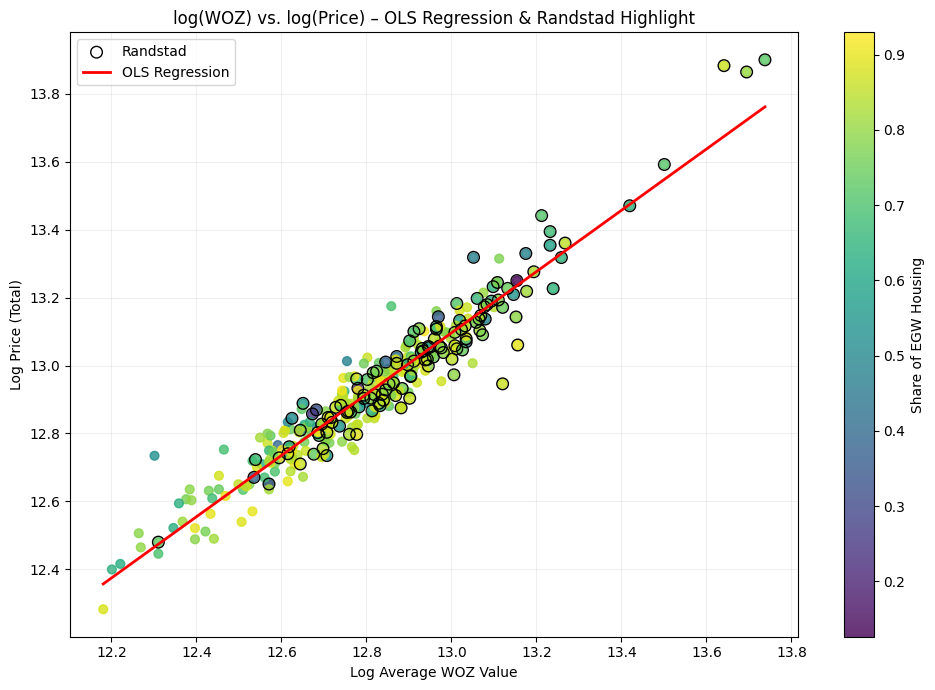

In [15]:
# ---------------------------------------------------------
# Visual 10.1 – log(WOZ) vs. log(Price)
# using df_residual (correct WOZ values)
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

# 1. Scatterplot (all municipalities)
scatter = plt.scatter(
    df_residual["log_woz_mean"],
    df_residual["log_price_total"],
    c=df_residual["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 2. Highlight Randstad municipalities
randstad = df_residual[df_residual["is_randstad"] == 1]

plt.scatter(
    randstad["log_woz_mean"],
    randstad["log_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    s=70,
    label="Randstad"
)

# 3. Regression
X = sm.add_constant(df_residual["log_woz_mean"])
y = df_residual["log_price_total"]
model_woz_log = sm.OLS(y, X).fit()

x_vals = np.linspace(
    df_residual["log_woz_mean"].min(),
    df_residual["log_woz_mean"].max(),
    200
)
y_pred = model_woz_log.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS Regression"
)

# 4. Labels, title, legend
plt.colorbar(scatter, label="Share of EGW Housing")
plt.xlabel("Log Average WOZ Value")
plt.ylabel("Log Price (Total)")
plt.title("log(WOZ) vs. log(Price) – OLS Regression & Randstad Highlight")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


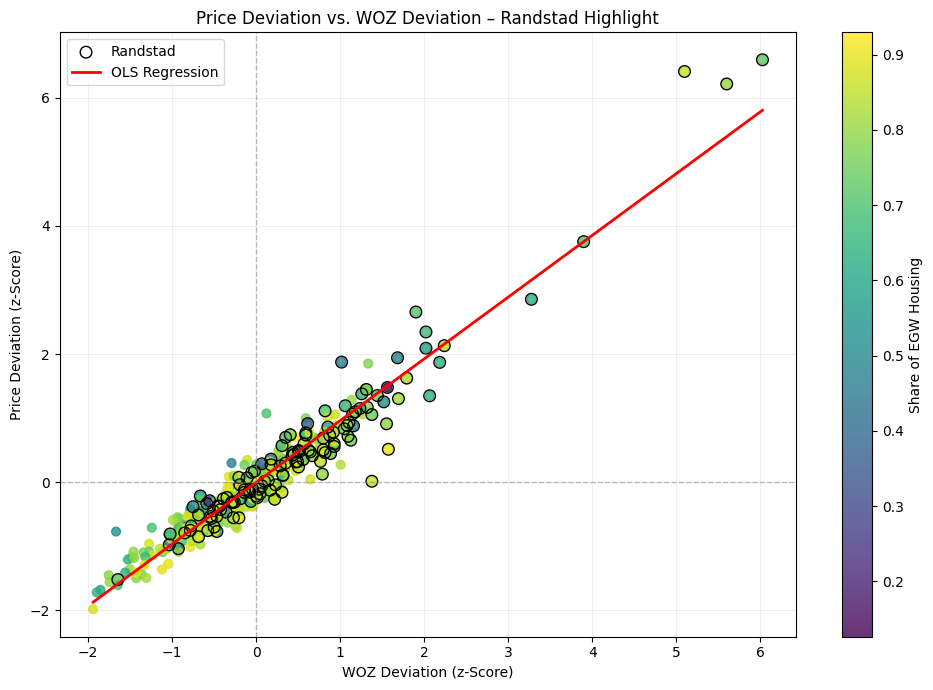

In [16]:
# ---------------------------------------------------------
# Visual 11 – Price Deviation vs. WOZ Deviation (z‑Scores)
# using df_residual (correct WOZ values)
# ---------------------------------------------------------

# 1. Compute z‑scores
df_residual["z_price_total"] = (
    df_residual["price_total"] - df_residual["price_total"].mean()
) / df_residual["price_total"].std()

df_residual["z_woz_mean"] = (
    df_residual["woz_mean"] - df_residual["woz_mean"].mean()
) / df_residual["woz_mean"].std()

plt.figure(figsize=(10, 7))

# 2. Scatterplot
scatter = plt.scatter(
    df_residual["z_woz_mean"],
    df_residual["z_price_total"],
    c=df_residual["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40
)

# 3. Highlight Randstad
randstad = df_residual[df_residual["is_randstad"] == 1]

plt.scatter(
    randstad["z_woz_mean"],
    randstad["z_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    s=70,
    label="Randstad"
)

# 4. Regression
X = sm.add_constant(df_residual["z_woz_mean"])
y = df_residual["z_price_total"]
model_dev = sm.OLS(y, X).fit()

x_vals = np.linspace(
    df_residual["z_woz_mean"].min(),
    df_residual["z_woz_mean"].max(),
    200
)
y_pred = model_dev.predict(sm.add_constant(x_vals))

plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS Regression"
)

# 5. Axes, title, legend
plt.axhline(0, color="grey", linewidth=1, linestyle="--", alpha=0.5)
plt.axvline(0, color="grey", linewidth=1, linestyle="--", alpha=0.5)

plt.colorbar(scatter, label="Share of EGW Housing")
plt.xlabel("WOZ Deviation (z‑Score)")
plt.ylabel("Price Deviation (z‑Score)")
plt.title("Price Deviation vs. WOZ Deviation – Randstad Highlight")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


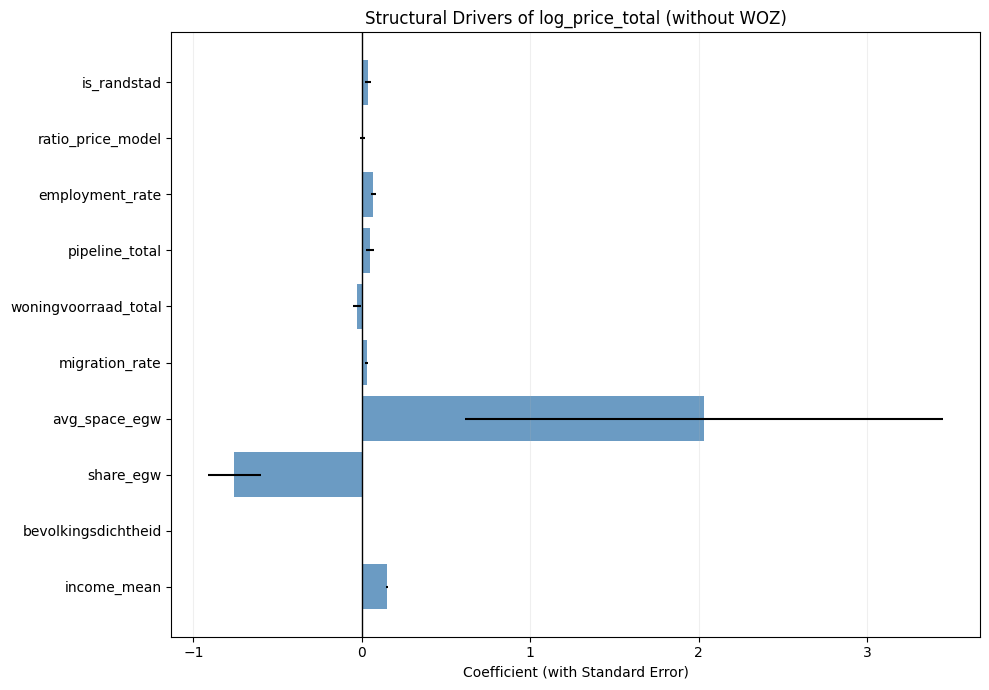

                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     67.23
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.64e-73
Time:                        17:30:43   Log-Likelihood:                 232.65
No. Observations:                 341   AIC:                            -443.3
Df Residuals:                     330   BIC:                            -401.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   11.4722 

In [17]:
# ---------------------------------------------------------
# Visual 12.1 – Structural Drivers of log_price_total (without WOZ)
# using df_residual (correct variables)
# ---------------------------------------------------------

import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Define structural variables (without WOZ)
features_A = [
    "income_mean",
    "bevolkingsdichtheid",
    "share_egw",
    "avg_space_egw",
    "migration_rate",
    "woningvoorraad_total",
    "pipeline_total",
    "employment_rate",
    "ratio_price_model",
    "is_randstad"
]

X_A = df_residual[features_A].copy()
X_A = sm.add_constant(X_A)
y_A = df_residual["log_price_total"]

# 2. Estimate model
model_A = sm.OLS(y_A, X_A).fit()

# 3. Extract coefficients (without intercept)
coef_A = model_A.params[1:]
errors_A = model_A.bse[1:]

# 4. Visualization
plt.figure(figsize=(10, 7))

plt.barh(
    coef_A.index,
    coef_A.values,
    xerr=errors_A.values,
    color="steelblue",
    alpha=0.8
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Structural Drivers of log_price_total (without WOZ)")
plt.xlabel("Coefficient (with Standard Error)")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# 5. Print model summary
print(model_A.summary())


Number of observations after cleaning: 341


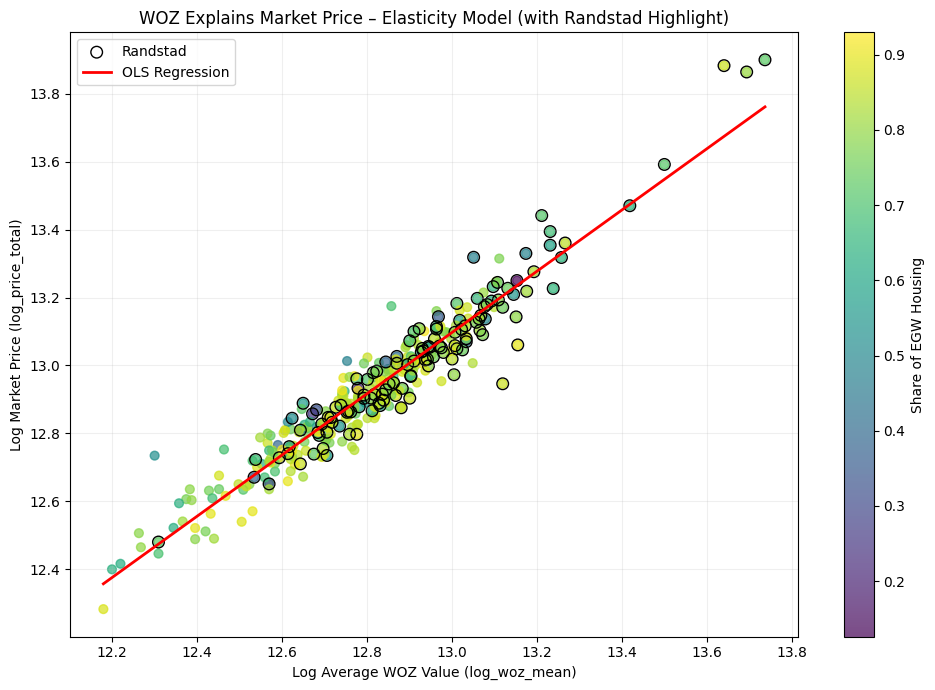

                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     3917.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          2.55e-188
Time:                        17:30:44   Log-Likelihood:                 474.60
No. Observations:                 341   AIC:                            -945.2
Df Residuals:                     339   BIC:                            -937.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.3602      0.185      7.364   

In [18]:
# ---------------------------------------------------------
# Visual 12.2 – WOZ explains Market Price (Elasticity Model)
# with Randstad Highlight
# using df_residual (correct WOZ values)
# ---------------------------------------------------------

import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Select relevant columns
cols_B = ["log_price_total", "log_woz_mean", "share_egw", "is_randstad"]

df_B = df_residual[cols_B].replace([np.inf, -np.inf], np.nan).dropna()

print("Number of observations after cleaning:", len(df_B))

# 2. Define variables
X_B = df_B["log_woz_mean"]
y_B = df_B["log_price_total"]

X_B_const = sm.add_constant(X_B)

# 3. Estimate OLS model
model_B = sm.OLS(y_B, X_B_const).fit()

# 4. Regression line
x_vals = np.linspace(df_B["log_woz_mean"].min(),
                     df_B["log_woz_mean"].max(), 200)
y_pred = model_B.predict(sm.add_constant(x_vals))

# 5. Plot
plt.figure(figsize=(10, 7))

# All municipalities
scatter = plt.scatter(
    df_B["log_woz_mean"],
    df_B["log_price_total"],
    alpha=0.7,
    s=40,
    c=df_B["share_egw"],
    cmap="viridis"
)

# Randstad highlight
randstad = df_B[df_B["is_randstad"] == 1]

plt.scatter(
    randstad["log_woz_mean"],
    randstad["log_price_total"],
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    s=70,
    label="Randstad"
)

# Regression line
plt.plot(
    x_vals,
    y_pred,
    color="red",
    linewidth=2,
    label="OLS Regression"
)

plt.colorbar(scatter, label="Share of EGW Housing")
plt.xlabel("Log Average WOZ Value (log_woz_mean)")
plt.ylabel("Log Market Price (log_price_total)")
plt.title("WOZ Explains Market Price – Elasticity Model (with Randstad Highlight)")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

# 6. Model summary
print(model_B.summary())


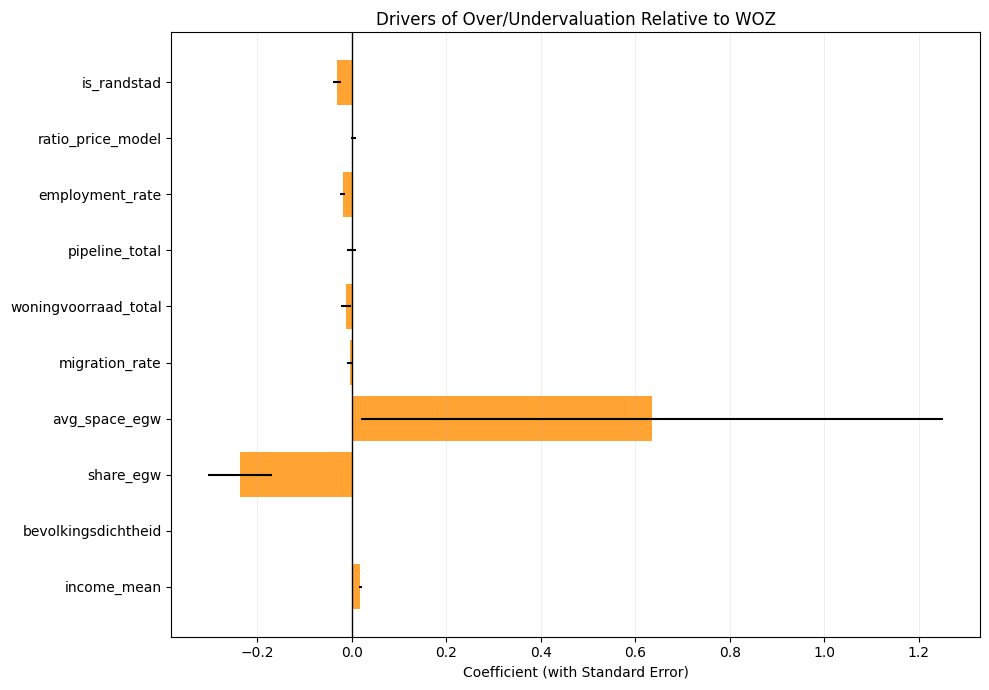

                            OLS Regression Results                            
Dep. Variable:           residual_woz   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     9.355
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.11e-13
Time:                        17:30:44   Log-Likelihood:                 517.16
No. Observations:                 341   AIC:                            -1012.
Df Residuals:                     330   BIC:                            -970.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.4287 

In [19]:
# ---------------------------------------------------------
# Visual 12.3 – Drivers of Over/Undervaluation Relative to WOZ
# using df_residual (correct WOZ residuals)
# ---------------------------------------------------------

import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# 1. Residuals already exist in df_residual:
#    df_residual["residual_woz"]

# 2. Structural variables
features_C = [
    "income_mean",
    "bevolkingsdichtheid",
    "share_egw",
    "avg_space_egw",
    "migration_rate",
    "woningvoorraad_total",
    "pipeline_total",
    "employment_rate",
    "ratio_price_model",
    "is_randstad"
]

# 3. Clean data
df_C = df_residual[["residual_woz"] + features_C] \
    .replace([np.inf, -np.inf], np.nan) \
    .dropna()

# 4. OLS model
X_C = sm.add_constant(df_C[features_C])
y_C = df_C["residual_woz"]

model_C = sm.OLS(y_C, X_C).fit()

# 5. Extract coefficients
coef_C = model_C.params[1:]
errors_C = model_C.bse[1:]

# 6. Visualization
plt.figure(figsize=(10, 7))

plt.barh(
    coef_C.index,
    coef_C.values,
    xerr=errors_C.values,
    color="darkorange",
    alpha=0.8
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Drivers of Over/Undervaluation Relative to WOZ")
plt.xlabel("Coefficient (with Standard Error)")
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# 7. Model summary
print(model_C.summary())


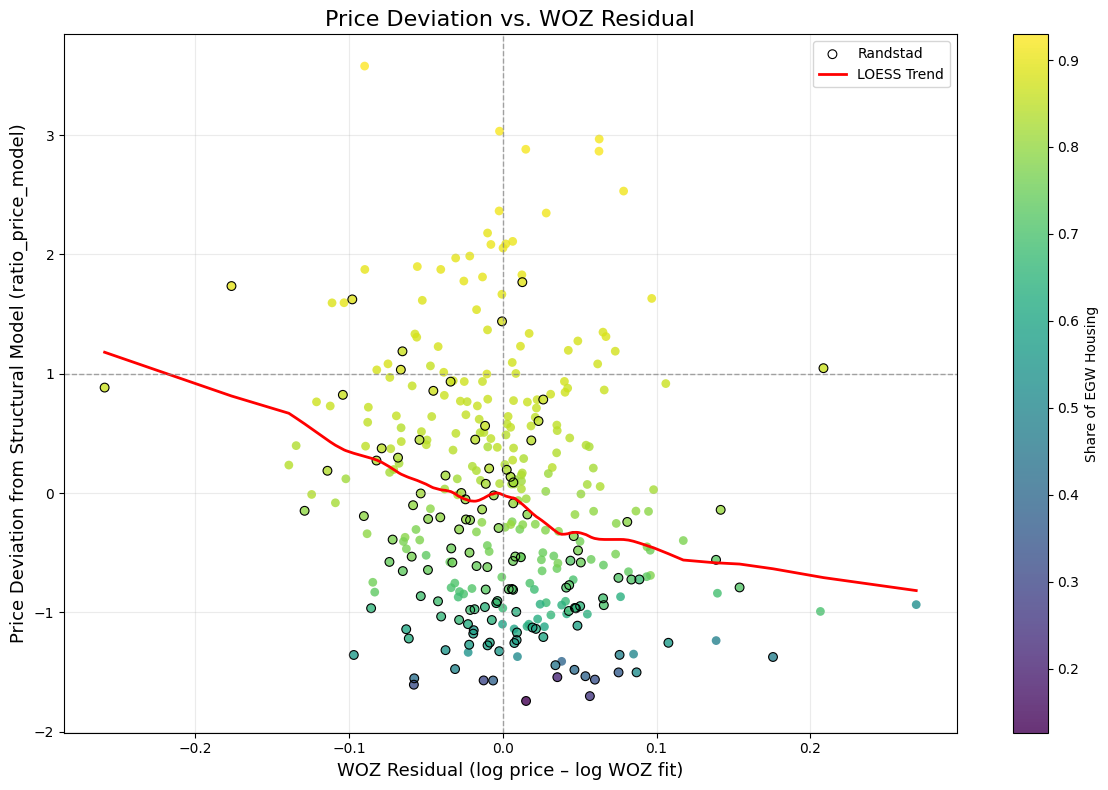

In [20]:
# ---------------------------------------------------------
# Visual 12.4.1 – Price Deviation vs. WOZ Residual
# using df_residual (correct residuals)
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.figure(figsize=(12, 8))

# 1. Scatterplot (color = EGW share)
scatter = plt.scatter(
    df_residual["residual_woz"],
    df_residual["ratio_price_model"],
    c=df_residual["share_egw"],
    cmap="viridis",
    alpha=0.8,
    s=40,
    edgecolor="none"
)

# 2. Randstad highlight
randstad = df_residual[df_residual["is_randstad"] == 1]

plt.scatter(
    randstad["residual_woz"],
    randstad["ratio_price_model"],
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    s=40,
    label="Randstad"
)

# 3. LOESS trendline
loess_result = lowess(
    df_residual["ratio_price_model"],
    df_residual["residual_woz"],
    frac=0.35
)

plt.plot(
    loess_result[:, 0],
    loess_result[:, 1],
    color="red",
    linewidth=2.0,
    label="LOESS Trend"
)

# 4. Axes, title, layout
cbar = plt.colorbar(scatter)
cbar.set_label("Share of EGW Housing")

plt.axhline(1, color="gray", linestyle="--", linewidth=1, alpha=0.7)
plt.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

plt.xlabel("WOZ Residual (log price – log WOZ fit)", fontsize=13)
plt.ylabel("Price Deviation from Structural Model (ratio_price_model)", fontsize=13)
plt.title("Price Deviation vs. WOZ Residual", fontsize=16)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


Cluster erfolgreich berechnet:
cluster_bcg
2    99
3    99
1    72
4    71
Name: count, dtype: int64
cluster_bcg in df_geo: True


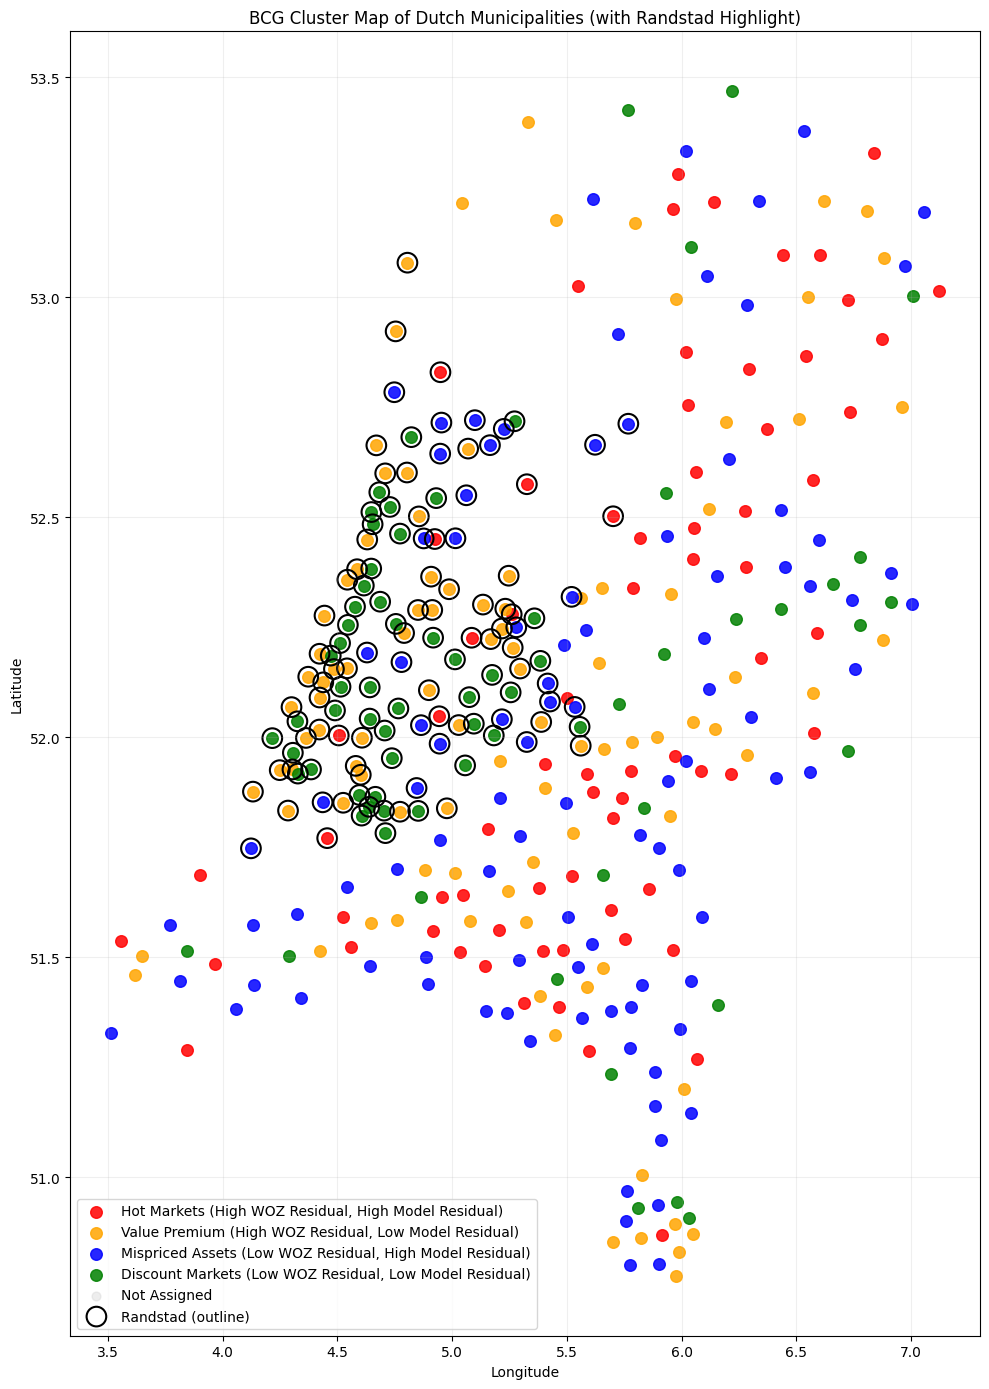

In [21]:
# ---------------------------------------------------------
# Visual 12.4.2 – BCG-Matrix on geo-map NL on base of visual 12.4.1
# ---------------------------------------------------------

# BCG-Cluster NEU berechnen (auf df_residual)

# Median-Schwellen bestimmen
x_med = df_residual["ratio_price_model"].median()
y_med = df_residual["residual_woz"].median()

# Clusterfunktion
def bcg_cluster(row):
    x = row["ratio_price_model"]
    y = row["residual_woz"]

    if x >= x_med and y >= y_med:
        return 1   # Hot Markets
    if x < x_med and y >= y_med:
        return 2   # Value Premium
    if x >= x_med and y < y_med:
        return 3   # Mispriced Assets
    if x < x_med and y < y_med:
        return 4   # Discount Markets
    return 0

# Cluster berechnen
df_residual["cluster_bcg"] = df_residual.apply(bcg_cluster, axis=1)

print("Cluster erfolgreich berechnet:")
print(df_residual["cluster_bcg"].value_counts())


# ---------------------------------------------------------
# 2. Geo-Daten laden und korrekt mergen
# ---------------------------------------------------------

df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")

df_geo = df_geo.merge(
    df_residual[["municipality_code", "cluster_bcg"]],
    on="municipality_code",
    how="left"
)

print("cluster_bcg in df_geo:", "cluster_bcg" in df_geo.columns)


# ---------------------------------------------------------
# 3. Karte zeichnen (mit Randstad-Umrandung)
# ---------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 14))

colors = {
    1: "red",       # Hot Markets
    2: "orange",    # Value Premium
    3: "blue",      # Mispriced Assets
    4: "green",     # Discount Markets
    0: "lightgrey"  # Not assigned
}

labels = {
    1: "Hot Markets (High WOZ Residual, High Model Residual)",
    2: "Value Premium (High WOZ Residual, Low Model Residual)",
    3: "Mispriced Assets (Low WOZ Residual, High Model Residual)",
    4: "Discount Markets (Low WOZ Residual, Low Model Residual)",
    0: "Not Assigned"
}

# --- 1. Clusterpunkte zeichnen ---
for c in [1, 2, 3, 4]:
    subset = df_geo[df_geo["cluster_bcg"] == c]
    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        s=70,
        color=colors[c],
        label=labels[c],
        alpha=0.85
    )

# --- 2. Nicht zugeordnete Gemeinden ---
subset0 = df_geo[df_geo["cluster_bcg"] == 0]
plt.scatter(
    subset0["longitude"],
    subset0["latitude"],
    s=40,
    color="lightgrey",
    label=labels[0],
    alpha=0.4
)

# --- 3. Randstad schwarz einkreisen ---
randstad_geo = df_geo[df_geo["municipality_code"].isin(
    df_residual[df_residual["is_randstad"] == 1]["municipality_code"]
)]

plt.scatter(
    randstad_geo["longitude"],
    randstad_geo["latitude"],
    s=200,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Randstad (outline)"
)

# --- 4. Titel & Layout ---
plt.title("BCG Cluster Map of Dutch Municipalities (with Randstad Highlight)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


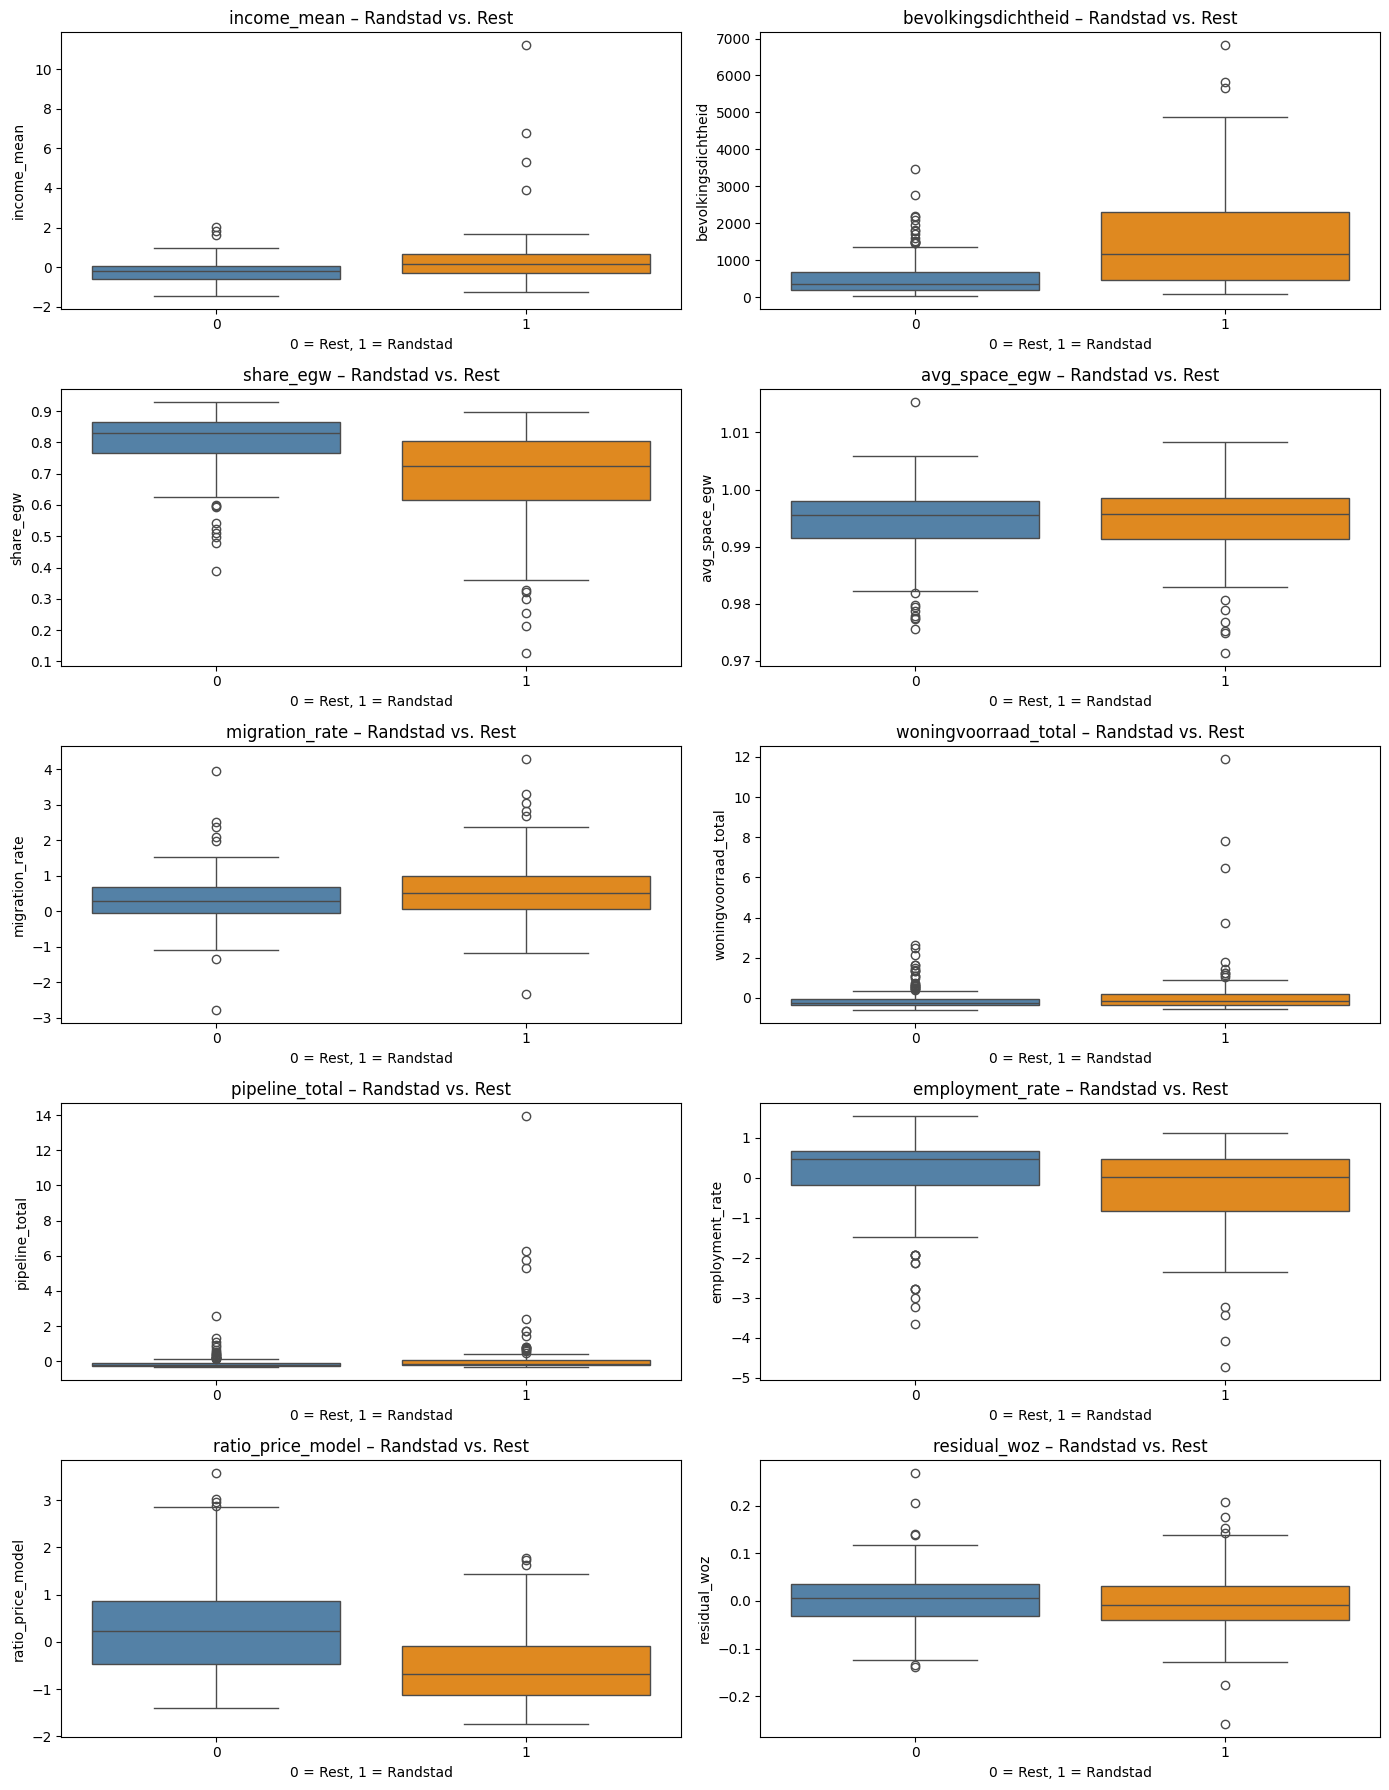

Mittelwerte Randstad (1) vs. Rest (0):


,income_mean,bevolkingsdichtheid,share_egw,avg_space_egw,migration_rate,woningvoorraad_total,pipeline_total,employment_rate,ratio_price_model,residual_woz
is_randstad,,,,,,,,,,
0,-0.233394,525.409302,0.804335,0.994447,0.336297,-0.112785,-0.139787,0.125133,0.309992,0.002245
1,0.398251,1575.674603,0.691167,0.994385,0.592002,0.192450,0.238525,-0.213521,-0.528955,-0.003830


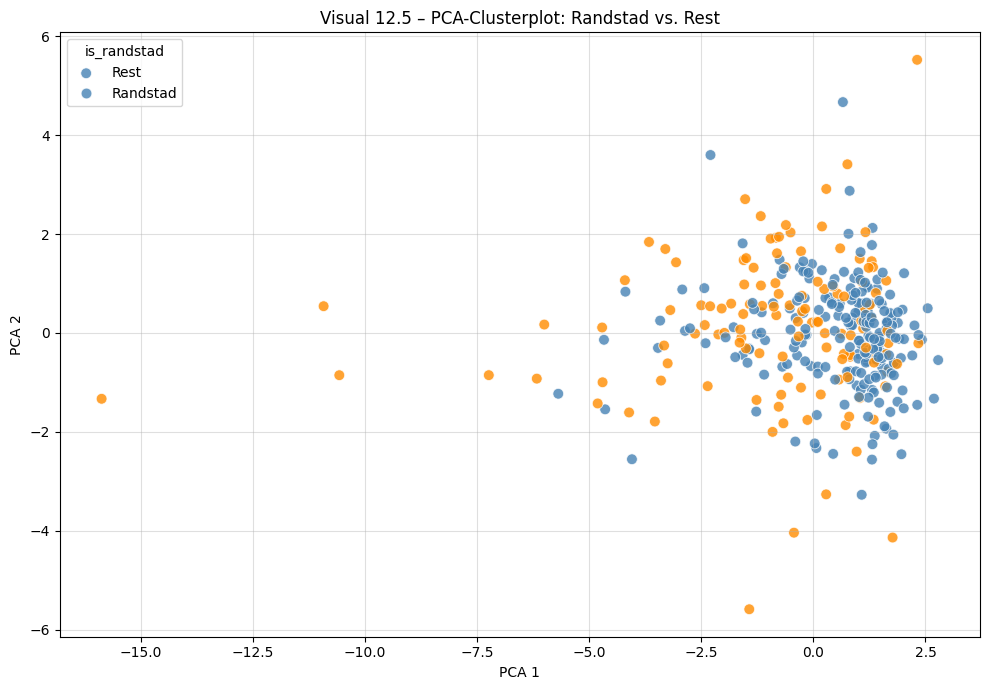

In [22]:
# ---------------------------------------------------------
# Visual 12.5 – Randstad vs. Rest (Clusteranalyse)
# using df_residual (correct variables)
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# 1. Strukturvariablen definieren
features_D = [
    "income_mean",
    "bevolkingsdichtheid",
    "share_egw",
    "avg_space_egw",
    "migration_rate",
    "woningvoorraad_total",
    "pipeline_total",
    "employment_rate",
    "ratio_price_model",
    "residual_woz"
]

# 2. Daten bereinigen (df_residual statt df!)
df_D = df_residual[["is_randstad"] + features_D] \
    .replace([np.inf, -np.inf], np.nan) \
    .dropna()

# 3. Boxplots für jede Variable
plt.figure(figsize=(14, 18))
for i, col in enumerate(features_D, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(
        data=df_D,
        x="is_randstad",
        y=col,
        hue="is_randstad",
        palette=["steelblue", "darkorange"],
        legend=False
    )
    plt.title(f"{col} – Randstad vs. Rest")
    plt.xlabel("0 = Rest, 1 = Randstad")
    plt.tight_layout()
plt.show()

# 4. Mittelwertvergleich
mean_table = df_D.groupby("is_randstad")[features_D].mean()
print("Mittelwerte Randstad (1) vs. Rest (0):")
display(mean_table)

# 5. PCA für 2D-Clusterplot
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_D[features_D])

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

df_D["pca1"] = pca_coords[:, 0]
df_D["pca2"] = pca_coords[:, 1]

# 6. PCA-Scatterplot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_D,
    x="pca1",
    y="pca2",
    hue="is_randstad",
    palette={0: "steelblue", 1: "darkorange"},  # explizite Zuordnung
    alpha=0.8,
    s=60
)

plt.title("Visual 12.5 – PCA-Clusterplot: Randstad vs. Rest")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.4)
plt.legend(title="is_randstad", labels=["Rest", "Randstad"])

plt.tight_layout()
plt.show()



In [23]:
# ---------------------------------------------------------
# INITIALISIERUNGSPROZESS NACH KERNEL-NEUSTART
# ---------------------------------------------------------

import numpy as np

# 1. EGW/MGW-Preise aus df übernehmen
df_residual["price_egw"] = df["price_egw"]
df_residual["price_mgw"] = df["price_mgw"]

# 2. Log-Variablen erzeugen
df_residual["log_price_egw"] = np.log(df_residual["price_egw"])
df_residual["log_price_mgw"] = np.log(df_residual["price_mgw"])

# 3. BCG-Cluster neu berechnen
x_med = df_residual["ratio_price_model"].median()
y_med = df_residual["residual_woz"].median()

def bcg_cluster(row):
    x = row["ratio_price_model"]
    y = row["residual_woz"]

    if x >= x_med and y >= y_med:
        return 1
    if x < x_med and y >= y_med:
        return 2
    if x >= x_med and y < y_med:
        return 3
    if x < x_med and y < y_med:
        return 4
    return 0

df_residual["cluster_bcg"] = df_residual.apply(bcg_cluster, axis=1)

# 4. Geo-Daten neu mergen
df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")
df_geo = df_geo.merge(
    df_residual[["municipality_code", "cluster_bcg"]],
    on="municipality_code",
    how="left"
)

print("Initialisierung abgeschlossen.")
print("log_price_egw:", "log_price_egw" in df_residual.columns)
print("log_price_mgw:", "log_price_mgw" in df_residual.columns)
print("cluster_bcg:", "cluster_bcg" in df_residual.columns)
print("cluster_bcg in df_geo:", "cluster_bcg" in df_geo.columns)


Initialisierung abgeschlossen.
log_price_egw: True
log_price_mgw: True
cluster_bcg: True
cluster_bcg in df_geo: True


Verbleibende Beobachtungen nach Cleaning: 341


<Figure size 1400x700 with 0 Axes>

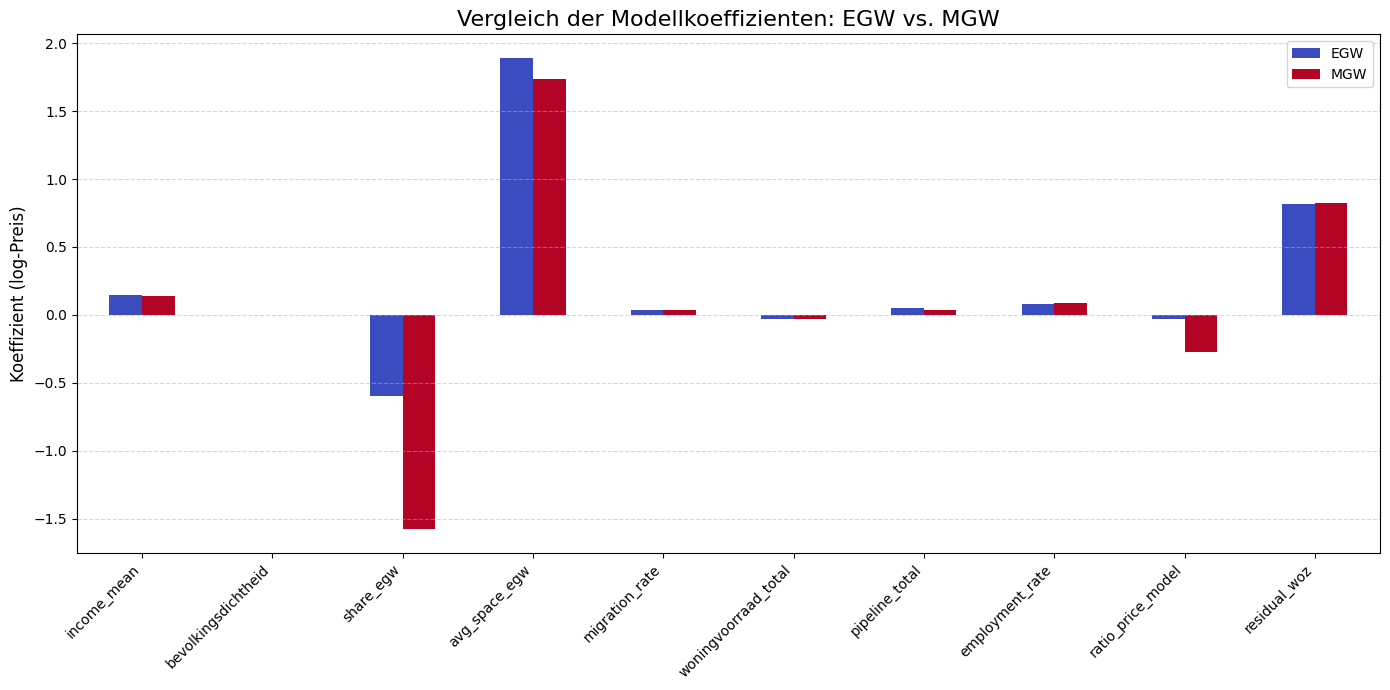


=== EGW Modell ===
                            OLS Regression Results                            
Dep. Variable:          log_price_egw   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     80.00
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           5.23e-82
Time:                        17:30:48   Log-Likelihood:                 245.35
No. Observations:                 341   AIC:                            -468.7
Df Residuals:                     330   BIC:                            -426.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [24]:
# ---------------------------------------------------------
# Visual 13 – EGW vs. MGW Modellkoeffizienten
# using df_residual (correct variables)
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# 1. Feature-Liste (Strukturvariablen)
# -----------------------------------------
features = [
    "income_mean",
    "bevolkingsdichtheid",
    "share_egw",
    "avg_space_egw",
    "migration_rate",
    "woningvoorraad_total",
    "pipeline_total",
    "employment_rate",
    "ratio_price_model",
    "residual_woz"
]

# -----------------------------------------
# 2. Modell-Daten vorbereiten
# -----------------------------------------
model_df = df_residual[features + ["log_price_egw", "log_price_mgw"]].copy()

model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

print("Verbleibende Beobachtungen nach Cleaning:", len(model_df))

# -----------------------------------------
# 3. EGW-Modell
# -----------------------------------------
X_egw = sm.add_constant(model_df[features])
y_egw = model_df["log_price_egw"]
model_egw = sm.OLS(y_egw, X_egw).fit()

# -----------------------------------------
# 4. MGW-Modell
# -----------------------------------------
X_mgw = sm.add_constant(model_df[features])
y_mgw = model_df["log_price_mgw"]
model_mgw = sm.OLS(y_mgw, X_mgw).fit()

# -----------------------------------------
# 5. Koeffizienten zusammenführen
# -----------------------------------------
coef_df = pd.DataFrame({
    "EGW": model_egw.params,
    "MGW": model_mgw.params
}).drop("const")

# -----------------------------------------
# 6. Plot
# -----------------------------------------
plt.figure(figsize=(14, 7))
coef_df.plot(kind="bar", figsize=(14, 7), colormap="coolwarm")
plt.title("Vergleich der Modellkoeffizienten: EGW vs. MGW", fontsize=16)
plt.ylabel("Koeffizient (log-Preis)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# -----------------------------------------
# 7. Optional: Modellzusammenfassungen anzeigen
# -----------------------------------------
print("\n=== EGW Modell ===")
print(model_egw.summary())

print("\n=== MGW Modell ===")
print(model_mgw.summary())


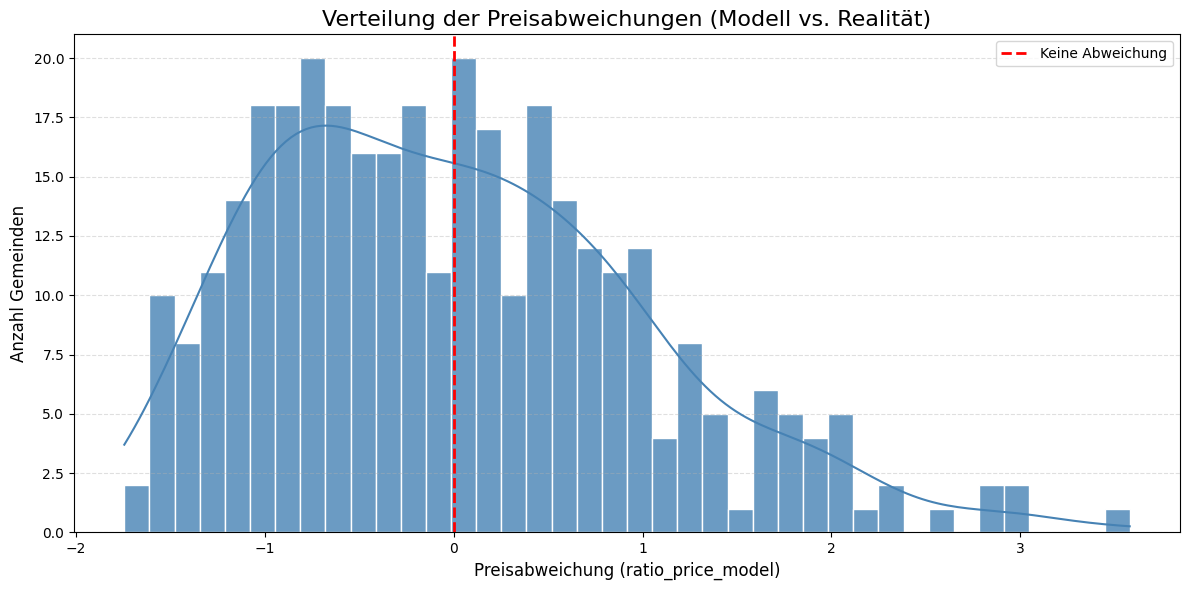

In [25]:
# -----------------------------------------
# Visual 14.1. – Histogramm + KDE der Preisabweichungen
# -----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(
    df['ratio_price_model'],
    kde=True,
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)

# Vertikale Linie bei 0 = keine Abweichung
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Keine Abweichung')

plt.title("Verteilung der Preisabweichungen (Modell vs. Realität)", fontsize=16)
plt.xlabel("Preisabweichung (ratio_price_model)", fontsize=12)
plt.ylabel("Anzahl Gemeinden", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

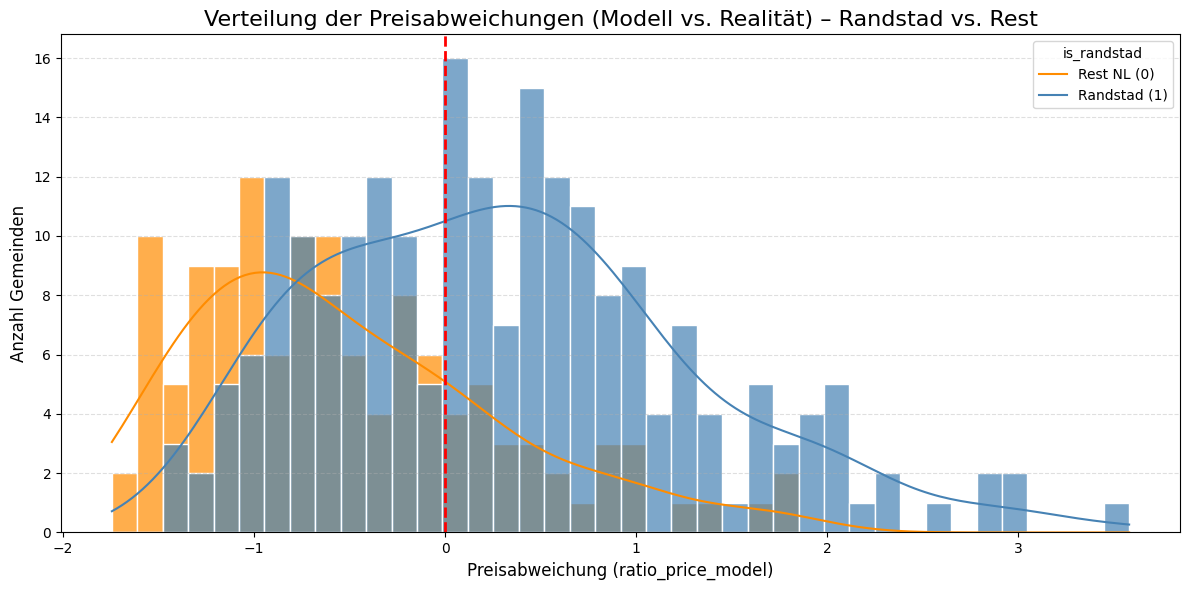

In [26]:
# -----------------------------------------
# Visual 14.2. – Histogramm + KDE nach Randstad
# -----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Farben definieren
palette = {
    0: "steelblue",   # Rest NL
    1: "darkorange"   # Randstad
}

# Histogramm + KDE für beide Gruppen
sns.histplot(
    data=df,
    x="ratio_price_model",
    hue="is_randstad",
    kde=True,
    bins=40,
    palette=palette,
    edgecolor="white",
    alpha=0.7
)

# Vertikale Linie bei 0 = keine Abweichung
plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Keine Abweichung")

plt.title("Verteilung der Preisabweichungen (Modell vs. Realität) – Randstad vs. Rest", fontsize=16)
plt.xlabel("Preisabweichung (ratio_price_model)", fontsize=12)
plt.ylabel("Anzahl Gemeinden", fontsize=12)

# Legende schöner machen
plt.legend(title="is_randstad", labels=["Rest NL (0)", "Randstad (1)"])

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


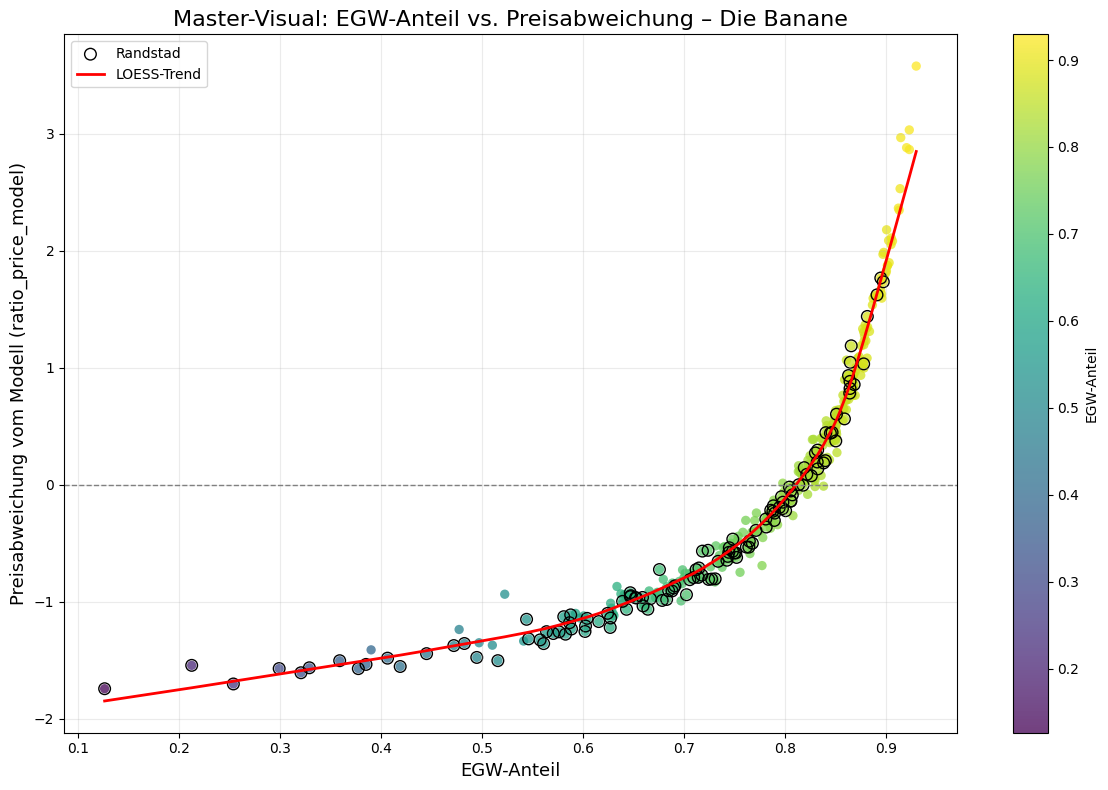

In [27]:
# -----------------------------------------
# Visual 15. – MASTER-VISUAL: EGW-Anteil vs. Preisabweichung (Banane)
# -----------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess


plt.figure(figsize=(12, 8))

# 1. Hauptscatter (Farbskala = EGW-Anteil)
scatter = plt.scatter(
    df["share_egw"],
    df["ratio_price_model"],
    c=df["share_egw"],
    cmap="viridis",
    alpha=0.75,
    s=45,
    edgecolor="none"
)

# 2. Randstad hervorheben (schwarzer Kreis)
randstad = df[df["is_randstad"] == 1]

plt.scatter(
    randstad["share_egw"],
    randstad["ratio_price_model"],
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    s=70,
    label="Randstad"
)

# 3. LOESS-Kurve (nichtlineare Trendlinie)
loess_result = lowess(
    df["ratio_price_model"],
    df["share_egw"],
    frac=0.35  # Glättungsgrad – 0.3–0.4 erzeugt die schönste Banane
)

plt.plot(
    loess_result[:, 0],
    loess_result[:, 1],
    color="red",
    linewidth=2.0,
    label="LOESS-Trend"
)

# 4. Horizontale Linie bei 0 (Modell stimmt)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# 5. Achsen, Titel, Layout
cbar = plt.colorbar(scatter)
cbar.set_label("EGW-Anteil")

plt.xlabel("EGW-Anteil", fontsize=13)
plt.ylabel("Preisabweichung vom Modell (ratio_price_model)", fontsize=13)
plt.title("Master-Visual: EGW-Anteil vs. Preisabweichung – Die Banane", fontsize=16)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
